# Loan Default Prediction & Credit Risk Analysis

**Project Goal:**  
Analyze borrower and loan information to identify default risk and build machine learning models that predict whether a loan will be fully paid or charged off.

**Problem Type:** Binary Classification

- `Fully Paid` = borrower repaid loan
- `Charged Off` = borrower defaulted / risky borrower


## 1. Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [61]:
df_info = pd.read_csv("lending_club_info.csv")
df = pd.read_csv("lending_club_loan_two.csv")
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [62]:
print("Shape:", df.shape)

Shape: (396030, 27)


## 3. Understand Column Descriptions

In [63]:
df_info.head(30)

,LoanStatNew,Description
0,loan_amnt,The listed amount of the loan applied for by t...
1,term,The number of payments on the loan. Values are...
2,int_rate,Interest Rate on the loan
3,installment,The monthly payment owed by the borrower if th...
4,grade,LC assigned loan grade
5,sub_grade,LC assigned loan subgrade
6,emp_title,The job title supplied by the Borrower when ap...
7,emp_length,Employment length in years. Possible values ar...
8,home_ownership,The home ownership status provided by the borr...
9,annual_inc,The self-reported annual income provided by th...


## 4. Basic Data Understanding

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [65]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [66]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
mort_acc,37795
emp_title,22927
emp_length,18301
title,1756
pub_rec_bankruptcies,535
revol_util,276


## 5. Target Variable Analysis

The target variable is `loan_status`.  
This tells us whether the loan was fully paid or charged off.

In [67]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


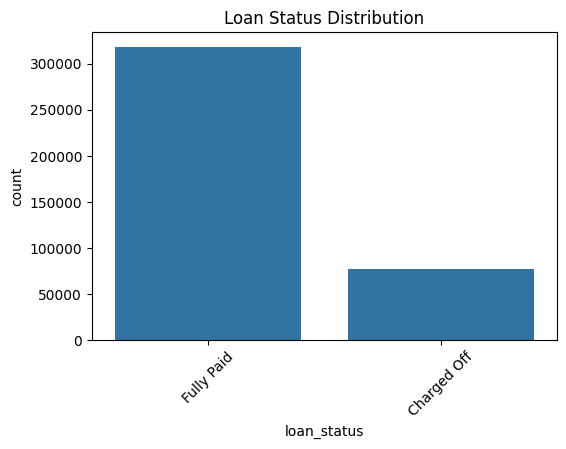

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.xticks(rotation=45)
plt.show()

### Target Variable Insight

Most borrowers fully paid their loans, while a smaller group were charged off. This shows that the dataset may have class imbalance, which is important to consider during modeling.

## 6. Exploratory Data Analysis (EDA)

### Loan Amount Distribution

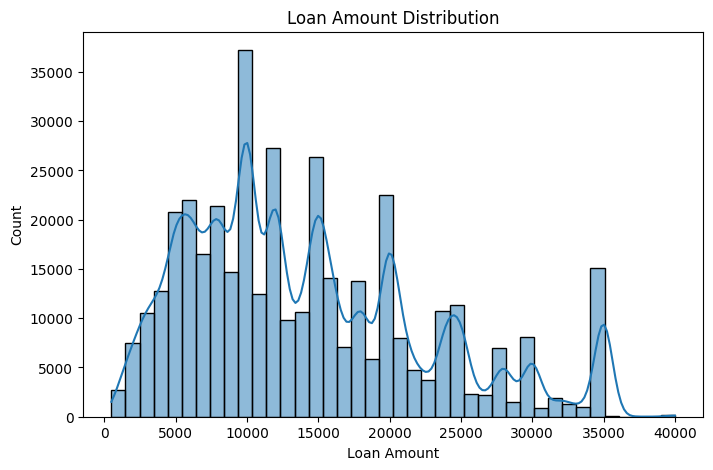

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=40, kde=True)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.show()

### Debt-to-Income Ratio by Loan Status

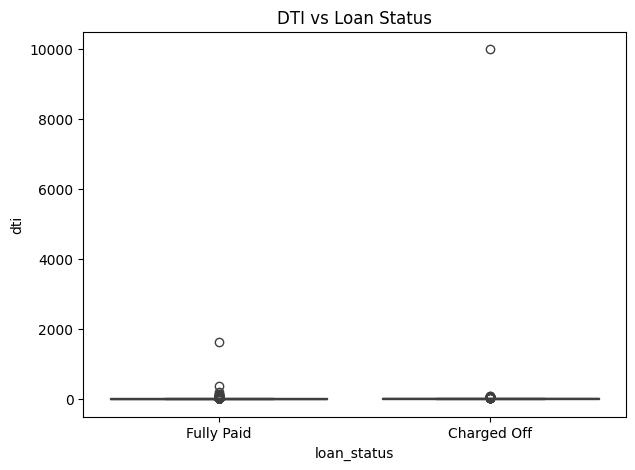

In [70]:
plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='dti', data=df)
plt.title('DTI vs Loan Status')
plt.show()

### Annual Income by Loan Status

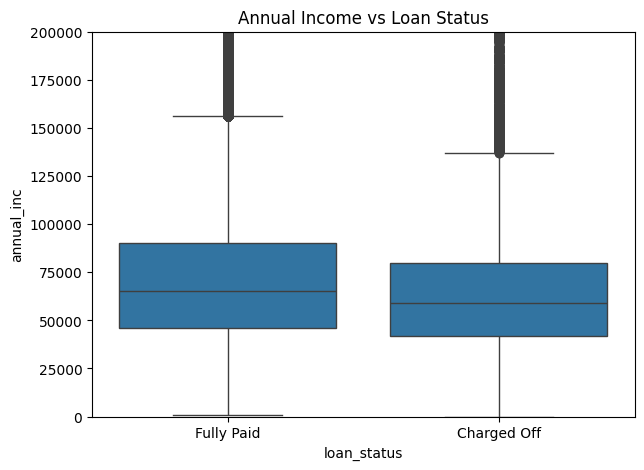

In [71]:
plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='annual_inc', data=df)
plt.title('Annual Income vs Loan Status')
plt.ylim(0, 200000)
plt.show()

### Loan Grade Distribution

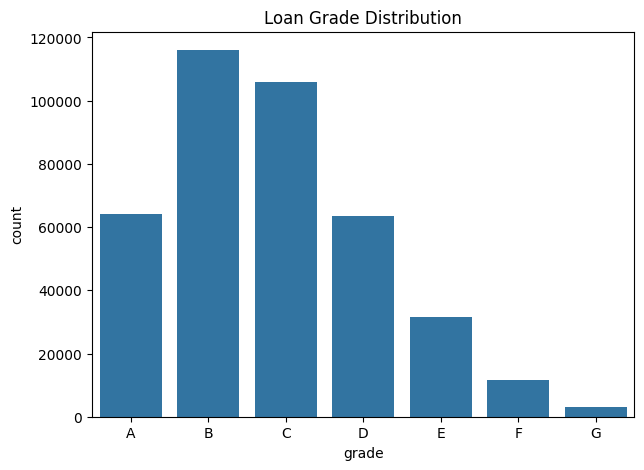

In [72]:
plt.figure(figsize=(7,5))
sns.countplot(x='grade', data=df, order=sorted(df['grade'].dropna().unique()))
plt.title('Loan Grade Distribution')
plt.show()

### Loan Purpose Distribution

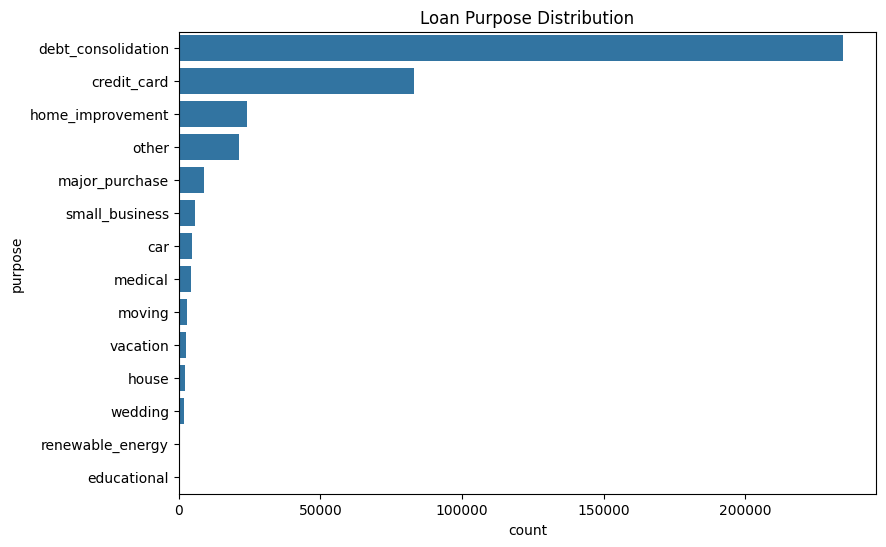

In [73]:
plt.figure(figsize=(9,6))
sns.countplot(y='purpose', data=df, order=df['purpose'].value_counts().index)
plt.title('Loan Purpose Distribution')
plt.show()

## 7. Correlation Analysis

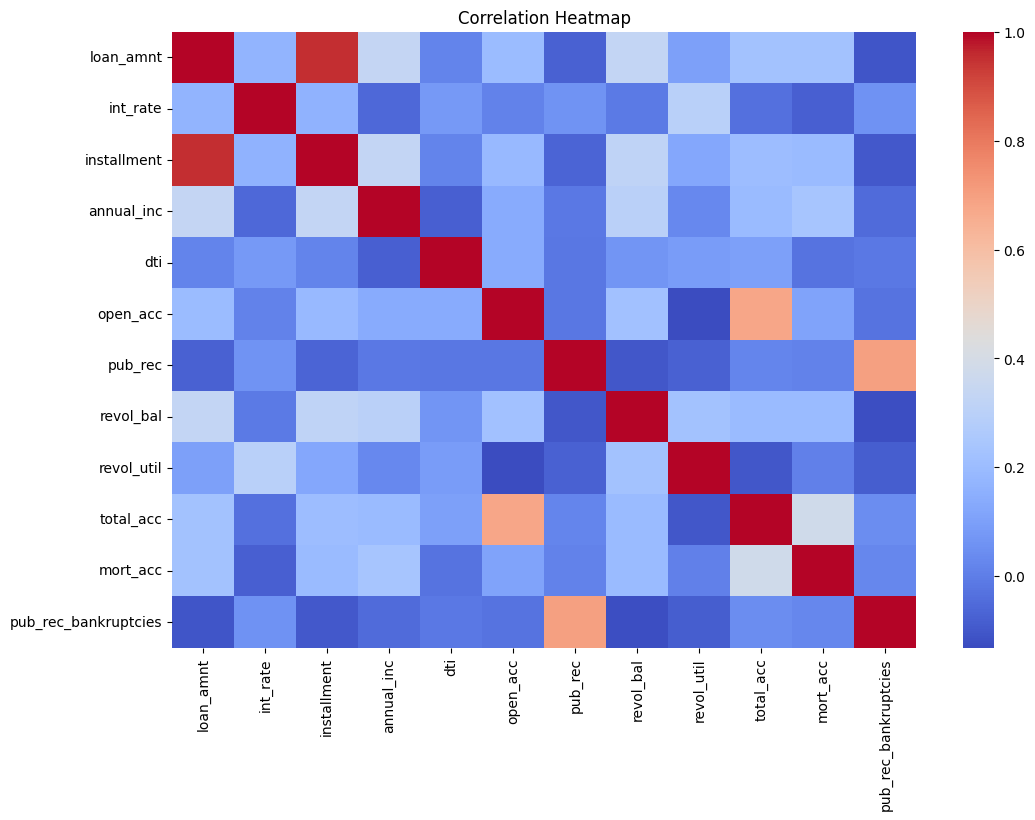

In [74]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 8. Data Cleaning


In [75]:
# Convert target variable to numeric
# Fully Paid = 1, Charged Off = 0
df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 1,
    'Charged Off': 0
})

# Drop rows where target is missing
df = df.dropna(subset=['loan_status'])

print(df['loan_status'].value_counts())

loan_status
1    318357
0     77673
Name: count, dtype: int64


In [76]:
# Drop unnecessary columns
drop_cols = ['emp_title', 'title', 'address']

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print(df.columns)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'dti', 'earliest_cr_line',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'application_type', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')


In [77]:
# Clean term column
if 'term' in df.columns:
    if df['term'].dtype == 'object':
        df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)
    else:
        df['term'] = df['term'].astype(float)

In [78]:
# Clean emp_length column
if 'emp_length' in df.columns:
    if df['emp_length'].dtype == 'object':
        df['emp_length'] = df['emp_length'].replace({
            '< 1 year': '0 years',
            '10+ years': '10 years'
        })

        df['emp_length'] = df['emp_length'].astype(str).str.extract(r'(\d+)').astype(float)
    else:
        df['emp_length'] = df['emp_length'].astype(float)

    df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

In [79]:
# Clean earliest_cr_line
if 'earliest_cr_line' in df.columns:
    if df['earliest_cr_line'].dtype == 'object':
        df['earliest_cr_line'] = df['earliest_cr_line'].astype(str).str.extract(r'(\d{4})').astype(float)
    else:
        df['earliest_cr_line'] = df['earliest_cr_line'].astype(float)

In [80]:
# Drop issue_d because it can create data leakage
# We do not want future/approval timing information to leak into prediction
if 'issue_d' in df.columns:
    df.drop('issue_d', axis=1, inplace=True)

In [81]:
# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [82]:
# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Total missing values after cleaning:', df.isnull().sum().sum())

Total missing values after cleaning: 0


In [83]:
print("Cleaning completed")
print("Remaining NaN:", df.isnull().sum().sum())
print("Shape:", df.shape)

Cleaning completed
Remaining NaN: 0
Shape: (396030, 23)


## 9. Feature Engineering and Encoding

In [84]:
# Drop grade because sub_grade gives more detailed grading information
if 'grade' in df.columns:
    df.drop('grade', axis=1, inplace=True)

# One-hot encode categorical columns
df = pd.get_dummies(df, drop_first=True)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Fill any remaining missing values
df = df.fillna(0)

print('Final dataset shape:', df.shape)
df.head()

Final dataset shape: (396030, 73)


,loan_amnt,term,int_rate,installment,emp_length,annual_inc,loan_status,dti,earliest_cr_line,open_acc,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,36.0,11.44,329.48,10.0,117000.0,1,26.24,1990.0,16.0,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,36.0,11.99,265.68,4.0,65000.0,1,22.05,2004.0,17.0,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,36.0,10.49,506.97,0.0,43057.0,1,12.79,2007.0,13.0,...,False,False,False,False,False,False,False,False,True,False
3,7200.0,36.0,6.49,220.65,6.0,54000.0,1,2.60,2006.0,6.0,...,False,False,False,False,False,False,False,False,True,False
4,24375.0,60.0,17.27,609.33,9.0,55000.0,0,33.95,1999.0,13.0,...,False,False,False,False,False,False,False,False,True,False


## 10. Define Features and Target

`X` contains independent variables/features.  
`y` contains the target variable.

In [85]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (396030, 72)
y shape: (396030,)


## 11. Train-Test Split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (316824, 72)
Testing shape: (79206, 72)


## 12. Feature Scaling

In [87]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 13. Model Training and Evaluation Function

In [88]:
def evaluate_model(model, model_name):
    print(f'Model: {model_name}')

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    print('Accuracy:', round(acc, 4))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    return acc

## 14. Logistic Regression Model

In [89]:
results = {}

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
results['Logistic Regression'] = evaluate_model(log_model, 'Logistic Regression')

Model: Logistic Regression
Accuracy: 0.6443
Confusion Matrix:
[[10353  5182]
 [22992 40679]]
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.67      0.42     15535
           1       0.89      0.64      0.74     63671

    accuracy                           0.64     79206
   macro avg       0.60      0.65      0.58     79206
weighted avg       0.77      0.64      0.68     79206



## 15. KNN Model

In [90]:
knn_model = KNeighborsClassifier(n_neighbors=5)
results['KNN'] = evaluate_model(knn_model, 'K-Nearest Neighbors')

Model: K-Nearest Neighbors
Accuracy: 0.7787
Confusion Matrix:
[[ 2552 12983]
 [ 4545 59126]]
Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.16      0.23     15535
           1       0.82      0.93      0.87     63671

    accuracy                           0.78     79206
   macro avg       0.59      0.55      0.55     79206
weighted avg       0.73      0.78      0.74     79206



## 16. Linear SVM Model


In [91]:
svm_model = LinearSVC(class_weight='balanced', max_iter=5000)
results['Linear SVM'] = evaluate_model(svm_model, 'Linear Support Vector Machine')

Model: Linear Support Vector Machine
Accuracy: 0.6418
Confusion Matrix:
[[10348  5187]
 [23181 40490]]
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.67      0.42     15535
           1       0.89      0.64      0.74     63671

    accuracy                           0.64     79206
   macro avg       0.60      0.65      0.58     79206
weighted avg       0.77      0.64      0.68     79206



## 17. Model Comparison


In [92]:
results_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': results.values()
}).sort_values(by='Accuracy', ascending=False)

results_df

,Model,Accuracy
1,KNN,0.778704
0,Logistic Regression,0.644295
2,Linear SVM,0.641845


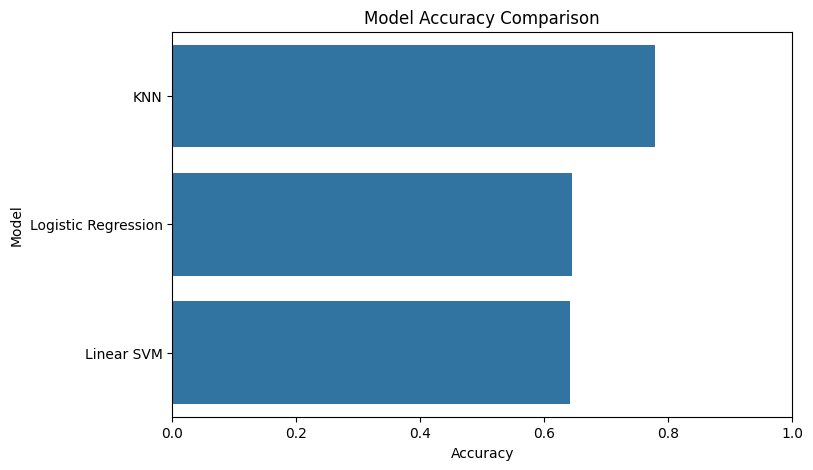

In [93]:
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=results_df)
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()

## 18. Feature Importance from Logistic Regression


In [94]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()

top_features = coefficients.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(15)

top_features[['Feature', 'Coefficient']]

,Feature,Coefficient
27,sub_grade_C4,-0.595156
28,sub_grade_C5,-0.591013
29,sub_grade_D1,-0.585164
26,sub_grade_C3,-0.584283
30,sub_grade_D2,-0.570259
25,sub_grade_C2,-0.562463
32,sub_grade_D4,-0.559496
31,sub_grade_D3,-0.543292
24,sub_grade_C1,-0.532893
33,sub_grade_D5,-0.518791


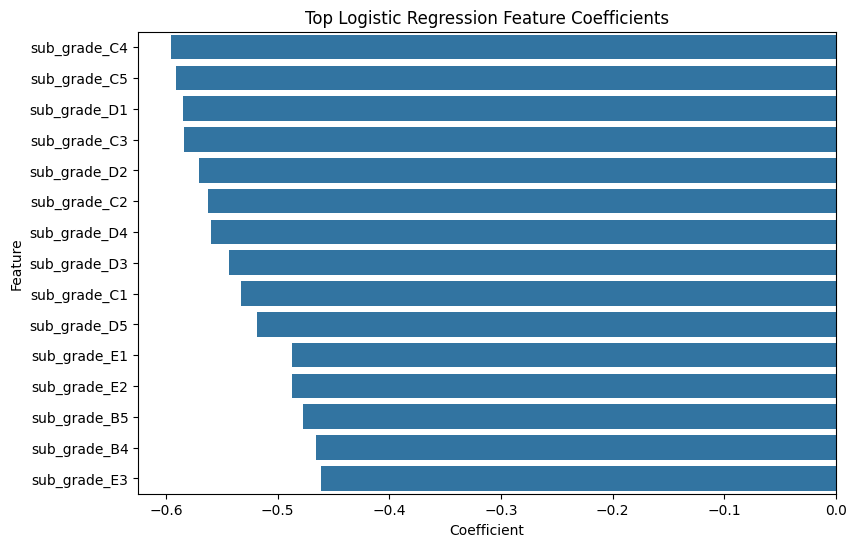

In [95]:
plt.figure(figsize=(9,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features.sort_values(by='Coefficient')
)
plt.title('Top Logistic Regression Feature Coefficients')
plt.show()

## Insight
The negative coefficients for sub-grade features indicate that borrowers in lower credit grades (such as C, D, and E) have a higher likelihood of default. As the grade worsens, the probability of loan repayment decreases. This confirms that loan grade is a strong indicator of borrower risk.


> Simple meaning:
*   Negative coefficient = risky borrower
*   Positive coefficient = safe borrower

## 19. Final Project Summary

In [96]:
print('Final Project Summary')
print('-' * 40)
print(f'Total records analyzed: {df.shape[0]}')
print(f'Total features after preprocessing: {X.shape[1]}')
print(f'Best model: {results_df.iloc[0]["Model"]}')
print(f'Best accuracy: {round(results_df.iloc[0]["Accuracy"], 4)}')

Final Project Summary
----------------------------------------
Total records analyzed: 396030
Total features after preprocessing: 72
Best model: KNN
Best accuracy: 0.7787


## Project Summary
This project focused on predicting loan default risk using a large-scale lending dataset of approximately 390,000 records with financial and credit-related features. After data cleaning, feature engineering, and scaling, multiple classification models were built and evaluated using accuracy, precision, recall, and F1-score. Logistic Regression achieved 64.43% accuracy with F1-scores of 0.42 for default (class 0) and 0.74 for fully paid (class 1), while Linear SVM showed similar performance. K-Nearest Neighbors performed best with 77.87% accuracy and a high 0.87 F1-score for class 1, but a low 0.23 F1-score for defaults, indicating difficulty in detecting risky borrowers despite strong overall accuracy. Feature importance analysis from Logistic Regression revealed that variables such as loan sub-grade (C, D, E), debt-to-income ratio, income level, and interest rate were key predictors, with negative coefficients for lower sub-grades indicating a higher likelihood of default; this aligns with real-world lending logic where poorer credit grades and higher financial burden increase risk. Overall, the results highlight that while KNN achieves higher accuracy, it underperforms in identifying defaults, emphasizing that F1-score for the default class and feature-driven insights are more critical than accuracy in credit risk modeling, where the primary goal is to correctly identify high-risk borrowers.